# **Proyecto 2:Clasificación de Estados de Imaginación Motora Mediante Señales EEG y Técnicas de BCI** 


### **Integrantes:**

- Sara Mejía Zapata
- María Camila Tobón Úsuga

**Asignatura:**  Bioseñales y Sistemas 

----

## **Consulta** 


*Consultar qué índices del EEG, adicionales a los realizados en el proyecto 1 basados en 
densidad espectral de potencia, mejoran la clasificación de estados en BCI.* 

#### **1.Common Spatial Patterns (CSP) – Patrón Espacial Común** 

El patrón espacial común o por su siglas en ingles CSP es un método de filtrado espacial supervisado ampliamente utilizado en sistemas BCI basados en imaginación motora. Está diseñado para identificar una combinación lineal de señales EEG que actúa como filtro espacial, proyectando la señal en un nuevo espacio de características que maximiza la potencia de banda para una clase mientras la minimiza para la otra. La potencia de banda derivada del CSP se utiliza posteriormente como característica discriminativa.

Supongamos que se recolectan señales EEG de dos tareas diferentes, expresadas en forma matricial como:

$$E_{1}^{(i)} \in \mathbb{R}^{Q \times P} \quad y \quad E_{2}^{(i)} \in \mathbb{R}^{Q \times P}$$

Donde Q es el número de canales, P es el número de puntos de muestreo y el superíndice (i) indica que los datos fueron recolectados en el i-ésimo ensayo. Se asume que todas las muestras han sido filtradas pasa banda en una frecuencia dada y que se les ha removido la media.Por lo que la matriz de covarianza es:

$$\bar{C}_l = \sum_{i=1}^{N_l} \frac{E_l^{(i)} (E_l^{(i)})^T}{trace(E_l^{(i)} (E_l^{(i)})^T)}$$

Donde $N_l$ es el número de ensayos de la clase $l$, $T$ es el operador de transposición y $\text{trace}( )$ es la traza de la matriz.

El propósito del CSP es encontrar la matriz de proyección de filtros espaciales W que maximiza el cociente de varianza entre las dos clases:

$$\max_{w} J(w) = \frac{w^T \bar{C}_1 w}{w^T \bar{C}_2 w} \quad s.t. \quad \|w\|_2 = 1$$

Donde $w \in \mathbb{R}^Q$ es un filtro espacial y $\|\cdot\|_2$ es la norma $l_2$.  

El problema de optimización se transforma en un problema de valores propios generalizado:

$$C_1 w = \lambda C_2 w$$

Un conjunto de filtros espaciales $W = [w_1, \dots, w_{2M}]$ está compuesto por $2M$ vectores propios correspondientes a los $M$ valores propios generalizados máximos y los $M$ mínimos.

Para un ensayo dado donde se recolecta una matriz de muestra $E$, el vector de características $X_{CSP} = [x_1, \dots, x_{2M}]$ se calcula como:

$$x_m = \log(\text{var}(w_m^T E)) \quad m = 1, 2, \dots, 2M$$

Donde $\text{var}(\cdot)$ denota la varianza. Para una señal unidimensional, la varianza equivale a la potencia de banda. En este sentido, la característica CSP es el logaritmo de la potencia de banda de las señales EEG filtradas espacialmente[1].

#### **2. Coherencia**

La coherencia en frecuencia es una técnica de análisis que cuantifica el grado de sincronización cortical entre la actividad registrada en dos derivaciones EEG, lo que permite hacer inferencias sobre las interrelaciones que diferentes áreas cerebrales mantienen entre sí atendiendo a una banda de frecuencia cualquiera. La comparación de los datos de coherencia obtenidos durante diversos estados de activación cerebral ha servido para establecer diferencias en la red topográfica de acoplamientos funcionales entre regiones corticales que caracterizan el funcionamiento normal de cada uno de estos estados.

Los valores de coherencia se calculan a partir de la aplicación de la transformada rápida de Fourier a épocas de EEG que contengan muestras representativas de una actividad determinada. Como resultado del algoritmo de Fourier se obtiene la matriz de densidad espectral cruzada, a partir de cuyos elementos pueden obtenerse los datos de coherencia EEG para cada par de derivaciones de interés mediante la siguiente fórmula 

$$Co_{xy} = \frac{|P_{xy}(f)|^2}{P_{xx}(f) \cdot P_{yy}(f)}$$

Donde:

* $x$ e $y$ equivalen a la actividad eléctrica cerebral registrada en cada uno de los dos electrodos seleccionados, cuya sincronización en el intervalo de frecuencia $f$ interesa analizar.
* $P_{xy}(f)$ es el valor de densidad espectral cruzada para ese par de señales.
* $P_{xx}(f)$ y $P_{yy}(f)$ representan los valores de densidad auto espectral que muestran cada una de las señales consideradas (diagonal de la matriz de densidad espectral cruzada). 

Los valores de coherencia que resultan de la aplicación de esta fórmula representan el cuadrado de la correlación entre la actividad cerebral registrada desde dos derivaciones EEG cualesquiera en un determinado intervalo de frecuencia. Esta información se expresa mediante valores que varían entre 0 y 1, extremos que indicarían la total independencia (0) o relación lineal perfecta (1) entre la actividad eléctrica registrada en dos áreas cerebrales más o menos distantes, atendiendo a un componente o banda de frecuencia determinada.

Sin embargo, el análisis de coherencia no informa sobre la dirección de la relación (signo del coeficiente), sino sobre la consistencia de fase o sincronización entre dos señales EEG en el dominio de la frecuencia.

Un elevado nivel de sincronización entre la actividad cerebral generada en diferentes estructuras corticales apunta, con una alta probabilidad, a la existencia de una relación funcional entre tales regiones. Por lo tanto, a partir de los datos obtenidos con la técnica de la coherencia podrían hacerse inferencias acerca de la distribución topográfica de las conexiones córticocorticales implicadas en la generación, control y/o mantenimiento de un estado cerebral específico. Asimismo, mediante el uso de esta técnica es posible detectar anomalías en el patrón de conectividad cortical.

En sistemas BCI basados en imaginación motora, la coherencia permite analizar cambios en la conectividad funcional entre regiones sensoriomotoras durante tareas de reposo e imaginación de movimiento. Particularmente, la coherencia entre electrodos como C3, Cz y C4 puede reflejar patrones de sincronización asociados a la imaginación de movimiento de mano derecha e izquierda, aportando información complementaria a la potencia espectral y mejorando la discriminación entre condiciones[2].

#### **3. Valor bloqueo de fase (Phase Locking Value)**

El valor de bloqueo de fase o PLV (Phase Locking Value) por sus siglas en ingles es es una medida de conectividad funcional ampliamente utilizada en sistemas BCI basados en ritmos sensoriomotores (SMR). Cuantifica el grado de sincronización de fase entre dos señales EEG, siendo una medida complementaria a la potencia de banda (BP), ya que ambas capturan información independiente sobre la actividad cerebral. Mientras que la BP refleja sincronización local, el PLV captura el acoplamiento de fase de larga distancia entre regiones cerebrales.

Para la extracción del PLV, las señales EEG son primero filtradas pasa banda en la banda de interés mediante un filtro FIR. Posteriormente se aplica la transformada de Hilbert para obtener la fase instantánea de cada señal. El PLV se calcula como

$$PLV = \left| \langle e^{j(\phi_i - \phi_j)} \rangle \right|$$

Donde:

* $\langle \cdot \rangle$ denota el promedio temporal sobre la ventana de análisis.
* $\phi_i$ y $\phi_j$ son las fases instantáneas de las señales EEG de los canales $i$ y $j$, calculadas mediante la transformada de Hilbert.
* $|\cdot|$ es el módulo del valor complejo resultante.

El resultado varía entre 0 y 1, donde 0 indica ausencia de sincronización de fase y 1 indica sincronización perfecta y constante entre las dos señales.

El PLV y la BP se modulan en direcciones opuestas durante las tareas motoras: mientras la BP disminuye sobre los sitios centrales durante el movimiento (ERD), el PLV entre electrodos como FCz, CP3 y C4 aumenta. Esto indica que ambas medidas capturan fenómenos cerebrales distintos e independientes. El PLV refleja un mayor acoplamiento de larga distancia durante el movimiento, mientras que la BP refleja mayor sincronización local en reposo

Adicionalmente, el PLV proporciona información única e independiente de la BP para la predicción de tareas motoras. El análisis de commonalidad demostró que la covarianza compartida entre BP y PLV con la condición de tarea fue pequeña (máximo $r^2 < 0.09$), confirmando que ambas medidas son fuentes de varianza independientes.

El PLV es una característica bien establecida en sistemas BCI basados en ritmos sensoriomotores. Los resultados muestran que el acoplamiento de fase entre electrodos en la región sensoriomotora (CP3, C4, FCz) aumenta significativamente durante tareas de movimiento de mano izquierda y derecha en las bandas mu (9-13 Hz) y beta (18-25 Hz), con efectos estadísticamente significativos ($p < 0.0001$) para todos los pares de electrodos evaluados[3].


#### **4. PLI (Phase Lag Index)**

El Phase Lag Index (PLI) es una medida de conectividad funcional que cuantifica la consistencia del desfase de fase entre dos señales EEG. Fue propuesto para abordar el problema de la conducción de volumen y los electrodos de referencia activos en la evaluación de conectividad funcional. 

El principio fundamental del PLI,si dos electrodos captan la misma fuente cerebral por conducción de volumen, su diferencia de fase será ≈ 0. El PLI ignora deliberadamente esas diferencias de fase nulas y solo cuenta las que tienen un desfase real, positivo o negativo, lo que indica una interacción genuina entre dos regiones cerebrales distintas.

A continuación se describe el paso a paso para el calculo de PLI:

*Paso 1:Transformada de Hilbert*

dada una señal x(t), se construye su señal analítica: 

$$z(t) = x(t) + j \cdot \mathcal{H}[x(t)]$$

La fase instantánea se extrae como:

$$\varphi(t) = \arctan \left( \frac{\text{Im}(z(t))}{\text{Re}(z(t))} \right)$$

*Paso 2 : Diferencia de fase entre dos canales*

Para dos canales $i$ y $j$:

$$\Delta\varphi(t) = \varphi_i(t) - \varphi_j(t)$$

*Paso 3 :Fórmula del PLI*

El PLI se calcula como:

$$\text{PLI} = | \langle \text{sign}(\Delta\varphi(t)) \rangle |$$

donde $|\cdot|$ denota el valor absoluto, $\langle \cdot \rangle$ denota la media aritmética y $\text{sign}(\cdot)$ es la función signo. El PLI varía entre 0 y 1, donde 0 indica ausencia de acoplamiento o una diferencia de fase centrada en 0 (excluyendo efectos instantáneos), mientras que 1 indica sincronización perfecta con una diferencia de fase constante distinta de 0.

La función signo actúa así:

$$\text{sign}(\Delta\varphi(t)) = \begin{cases} +1 & \text{si } \Delta\varphi(t) > 0 \\ 0 & \text{si } \Delta\varphi(t) = 0 \\ -1 & \text{si } \Delta\varphi(t) < 0 \end{cases}$$

Un valor de PLI=0 indica ausencia de acoplamiento consistente o diferencias de fase centradas alrededor de cero, generalmente asociadas a conducción de volumen. Valores intermedios indican sincronización parcial entre señales, mientras que PLI=1 representa una diferencia de fase perfectamente consistente y distinta de cero.[4].

#### **5. Entropía de Muestra (Sample Entropy — SampEn)**

En términos generales, la SampEn mide la complejidad o irregularidad de una serie temporal: cuanto más impredecible es la señal, mayor es su valor de entropía. Aplicada al EEG, permite distinguir entre diferentes estados cerebrales, por ejemplo entre reposo e imaginación motora, dado que la actividad cerebral cambia su grado de regularidad según la tarea mental que se realiza.

se calcula de la siguiente manera:

Dada una serie de tiempo de $N$ puntos $u = \{u(1), u(2), \dots, u(N)\}$, el cálculo sigue estos pasos:

Se Construcyen d vectores de plantilla de longitud $m$:

$$\mathbf{x}_m(i) = \{u(i), u(i+1), \dots, u(i+m-1)\}, \quad i = 1, 2, \dots, N-m$$

la Distancia entre vectores (distancia de Chebyshev):

$$d[\mathbf{x}_m(i), \mathbf{x}_m(j)] = \max_{k=0, \dots, m-1} |u(i+k) - u(j+k)|$$

Se realiza un conteo de pares similares para longitud $m$:**, para esto se cuenta cuántos pares de vectores tienen una distancia menor que la tolerancia $r$, excluyendo la auto-comparación ($i \neq j$):

$$B^m(r) = \frac{1}{N-m} \sum_{i=1}^{N-m} B_i^m(r)$$

Donde $B_i^m(r)$ es el número de $j \neq i$ tales que $d[\mathbf{x}_m(i), \mathbf{x}_m(j)] < r$, dividido entre $N-m-1$.

Luego se realiza un conteo de pares similares para longitud $m+1$:**

$$A^m(r) = \frac{1}{N-m} \sum_{i=1}^{N-m} A_i^m(r)$$

Donde $A_i^m(r)$ cuenta los pares similares al extender los vectores a longitud $m+1$.

por último la formula final de $\text{SampEn}$ es:  

$$\text{SampEn}(m, r, N) = -\ln \left( \frac{A^m(r)}{B^m(r)} \right)$$

El cociente $\frac{A^m(r)}{B^m(r)}$ es la probabilidad condicional de que dos secuencias similares para longitud $m$ sigan siendo similares al agregar un punto más ($m+1$). La $\text{SampEn}$ es el logaritmo natural negativo de esa probabilidad[5].

#### 6. Entropía de Permutación (Permutation Entropy)

#### 7. Transformada Wavelet (CWT/WPD)

#### 8. Modelo Autorregresivo (AR — Autoregressive Model)

#### 9. Causalidad de Granger (Granger Causality)

#### 10. Fase Instantánea (Instantaneous Phase)

#### 11. ERD/ERS (Event-Related Desynchronization / Event-Related Synchronization)

ERD (Event-Related Desynchronization) y ERS (Event-Related Synchronization) corresponden a cambios en la potencia espectral del EEG asociados a tareas motoras o de imaginación motora. Estos fenómenos se presentan principalmente en las bandas Mu (8–13 Hz) y Beta (13–30 Hz) sobre la corteza sensoriomotora.

Durante tareas de imaginación motora, se produce una disminución de potencia espectral en las bandas Mu y Beta, fenómeno conocido como ERD. Esta desincronización refleja activación cortical relacionada con preparación o imaginación del movimiento, aun cuando no existe ejecución física real. Posteriormente, especialmente en la banda Beta, puede observarse un incremento de potencia denominado ERS, asociado a procesos de recuperación o desactivación cortical después de la tarea motora.

En sistemas BCI basados en imaginación motora, ERD/ERS constituye una de las características más utilizadas debido a que permite diferenciar entre estados de reposo y tareas motoras imaginadas. Además, los patrones de desincronización suelen aparecer de manera contralateral: durante imaginación de movimiento de la mano derecha se observan mayores cambios sobre C3, mientras que durante imaginación de la mano izquierda los cambios predominan sobre C4.

La medida ERD/ERS se calcula comparando la potencia espectral durante la tarea respecto a una condición baseline o de reposo:

$$\text{ERD/ERS}(\%) = \frac{P_{\text{tarea}} - P_{\text{reposo}}}{P_{\text{reposo}}} \times 100$$

Donde:

* $P_{\text{reposo}}$ corresponde a la potencia espectral en reposo.
* $P_{\text{tarea}}$ corresponde a la potencia durante imaginación motora.

Valores negativos indican desincronización (ERD), mientras que valores positivos indican sincronización (ERS).

En sistemas BCI basados en imaginación motora, ERD/ERS es uno de los índices más utilizados debido a que permite diferenciar entre estados de reposo y tareas motoras imaginadas mediante cambios en la actividad cortical[6]. 


*Escoger por lo menos tres índices que se puedan implementar en Python, se pueden usar 
librerías, explicar la medida y su uso en los datos del proyecto*

De los índices consultados previamente, se seleccionaron ERD/ERS, coherencia y CSP debido a que proporcionan información complementaria a la densidad espectral de potencia obtenida en el proyecto anterior. Estos índices permiten analizar cambios de activación cortical, conectividad funcional y patrones espaciales asociados a tareas de imaginación motora, aspectos ampliamente utilizados en sistemas BCI basados en EEG.

**ERD/ERS(Event-Related Desynchronization / Event-Related Synchronization)** 

El índice ERD/ERS fue seleccionado porque permite identificar cambios de activación cortical asociados a imaginación motora mediante la comparación de la potencia espectral respecto a una condición de reposo. Este índice resulta especialmente útil para diferenciar estados de reposo e imaginación de movimiento en las bandas Mu y Beta sobre canales sensoriomotores como C3, Cz y C4.

En Python, ERD/ERS puede implementarse utilizando librerías como MNE-Python, NumPy y SciPy, las cuales permiten realizar filtrado, segmentación temporal y cálculo de potencia espectral en señales EEG[7].
 

**Coherencia**

La coherencia fue seleccionada debido a que permite analizar la conectividad funcional entre diferentes regiones corticales, proporcionando información adicional a la actividad espectral local obtenida mediante PSD. Este índice permite evaluar cambios en la sincronización entre canales EEG durante tareas de imaginación motora.

En Python, la coherencia puede calcularse utilizando funciones de análisis espectral disponibles en SciPy y MNE-Python, facilitando el estudio de sincronización entre pares de canales EEG[8].


**CSP (Common Spatial Patterns)** 

El CSP fue seleccionado debido a que es una de las técnicas más utilizadas en sistemas BCI basados en imaginación motora para extracción de características espaciales discriminativas. Este método mejora la separación entre clases al resaltar patrones espaciales asociados a diferentes tareas motoras imaginadas.

En Python, CSP puede implementarse mediante librerías como MNE-Python y Scikit-learn, las cuales incluyen herramientas para procesamiento espacial, extracción de características y clasificación de señales EEG

## **Plan de análisis** 

*on la información recolectada, del entregable 1 y del punto anterior, proponer una metodología de análisis que permita evidenciar la diferencia en ritmos cerebrales asociados a las condiciones de: reposo, imaginación de movimiento mano derecha, imaginación de movimiento mano izquierda*


### **Metodología**

Para evidenciar la diferencia en los ritmos cerebrales asociados a las cuatro condiciones de estudio (reposo, movimiento e imaginación de la mano izquierda y derecha), se propone la siguiente metodología, cabe aclarar que aunque los datos ya se encuentran adquiridos, la selección de canales equivalentes a los electrodos C3, C4 y Cz es fundamental para el análisis, ya que corresponden a la corteza sensoriomotora involucrada en el movimiento de las manos.

*1. Selección de canales (electrodos relevantes)* 

A partir del conjunto de datos proporcionado, se seleccionarán los canales correspondientes a la región sensoriomotora, especialmente aquellos cercanos a las posiciones C3, C4 y Cz del sistema internacional 10-20. 

La relevancia de estos canales radica en su vinculación funcional con las tareas motoras:

* C3: se encuentra asociado al control y la activación de la mano derecha.

* C4: se asocia directamente con el control de la mano izquierda.

La selección de estos canales permite analizar las modulaciones corticales presentes durante tareas de imaginación motora.

*2. Segmentación de señales EEG*

Las señales EEG serán organizadas únicamente en las condiciones de interés para este proyecto:

* Reposo.
* Imaginación de movimiento de mano derecha.
* Imaginación de movimiento de mano izquierda.

Posteriormente, las señales serán segmentadas en épocas temporales asociadas a cada evento experimental utilizando las marcas de anotación incluidas en la base de datos.

*3. Preprocesamiento de las señales* 

Con el fin de mejorar la calidad de las señales EEG y aislar la actividad relacionada con imaginación motora, se aplicarán las siguientes etapas de procesamiento:

* Eliminación de tendencia (detrend).
* Filtrado pasa banda entre 8 y 30 Hz.
* Segmentación temporal en épocas.
* Corrección baseline respecto al periodo de reposo.

El filtrado entre 8 y 30 Hz permitirá conservar principalmente las bandas:

* Mu (8–13 Hz).
* Beta (13–30 Hz).

las cuales están directamente asociadas a actividad sensoriomotora e imaginación de movimiento.


*4. Cálculo de densidad espectral de potencia (PSD)*

Para cada canal y condición experimental se calculará la densidad espectral de potencia (PSD) mediante el método de Welch.

A partir de la PSD se obtendrán medidas espectrales sobre las bandas Mu y Beta, permitiendo observar cambios de potencia asociados a imaginación motora.

*5. Cálculo del índice ERD/ERS*

Se calculará el índice ERD/ERS en las bandas Mu y Beta comparando la potencia espectral durante imaginación motora respecto a una condición baseline de reposo.

Este análisis permitirá identificar:

* Desincronización cortical (ERD) durante imaginación motora.
* Posibles procesos de resincronización (ERS).

Se espera observar:

* mayor ERD sobre C3 durante imaginación de mano derecha,
* mayor ERD sobre C4 durante imaginación de mano izquierda.



*6. Análisis de coherencia* 

Se calculará la coherencia entre pares de canales de interés, principalmente:

* C3–Cz,
* Cz–C4,
* C3–C4.

Este análisis permitirá evaluar cambios en la conectividad funcional entre regiones sensoriomotoras durante las tareas de imaginación motora.

La coherencia complementa el análisis espectral debido a que permite estudiar la sincronización entre diferentes regiones corticales y no únicamente la actividad local de cada canal.

*7. Extracción de características mediante CSP*

Se aplicará el método Common Spatial Patterns (CSP) para extraer características espaciales discriminativas entre las diferentes condiciones experimentales.

El CSP permitirá maximizar las diferencias espaciales entre:

* reposo,
* imaginación de mano derecha,
* imaginación de mano izquierda,

resaltando patrones asociados a activación cortical contralateral en regiones motoras.

Las características obtenidas mediante CSP serán utilizadas posteriormente en la etapa de clasificación.

*8. Construcción del dataframe*

Se implementará una rutina que procese automáticamente todos los archivos de la base de datos y almacene las características extraídas en un dataframe.

Cada fila del dataframe corresponderá a un registro experimental e incluirá:

* sujeto,
* condición evaluada,
* canal EEG,
* PSD en bandas Mu y Beta,
* ERD/ERS,
* coherencia,
* características CSP.

Esto permitirá realizar comparaciones estadísticas y alimentar posteriormente los algoritmos de clasificación.

*9. Análisis estadístico de los índices*

Una vez construido el dataframe, se realizará un análisis estadístico de los índices extraídos con el objetivo de identificar cuáles presentan mayores diferencias entre las condiciones evaluadas:

* Reposo
* Imaginación de movimiento de mano izquierda
* Imaginación de movimiento de mano derecha

Para ello se emplearán herramientas de estadística descriptiva y representaciones gráficas que permitan comparar el comportamiento de los índices en cada condición experimental.

*10. Planteamiento y evaluación de hipótesis*

Posteriormente se formularán hipótesis nulas y alternativas para determinar si existen diferencias estadísticamente significativas entre las condiciones analizadas.

La selección de las pruebas estadísticas dependerá del comportamiento de los datos y del cumplimiento de supuestos de normalidad, aplicando pruebas paramétricas o no paramétricas según corresponda.

*11. Selección de características para clasificación* 

A partir de los resultados estadísticos obtenidos, se seleccionarán los índices y canales que presenten mayor capacidad discriminativa entre las condiciones experimentales.

Únicamente estas características serán utilizadas posteriormente en las etapas de clasificación.

*12. Estrategia de validación cruzada (K-Fold)* 

Para el entrenamiento y evaluación de los modelos de clasificación se implementará una estrategia de validación cruzada basada en K-Fold.

Este procedimiento permitirá dividir el conjunto de datos en múltiples particiones de entrenamiento y validación, reduciendo el sesgo asociado a una única división de los datos y permitiendo una evaluación más robusta del desempeño de los modelos.

*13. Clasificación mediante diferentes arquitecturas* 

Posteriormente se implementarán y compararán diferentes arquitecturas de clasificación utilizando los índices seleccionados previamente.

El desempeño de cada modelo será evaluado mediante:

Exactitud de clasificación
Matrices de confusión
Comparación entre condiciones experimentales

*14. Implementación de SVM y XGBoost*

Finalmente, se realizará la implementación y análisis de algoritmos de aprendizaje automático basados en:

Máquina de Soporte Vectorial (SVM)
Extreme Gradient Boosting (XGBoost)

Para cada algoritmo se discutirá:

Su funcionamiento general
La estrategia de entrenamiento utilizada
El desempeño obtenido en la clasificación de condiciones de imaginación motora utilizando señales EEG.

<p align="center">
  <img src="metodologia.png" alt="Boxplot RMS" width="1000"><br>
  <b>Figura 2.</b> Metodología adquisición de señal
</p> 

## **Programación**

*1. Crear una función que reciba una señal de EEG procesada y permita obtener la densidad espectral de potencia y los índices adicionales consultados en un conjunto 
de canales de interés*

Para el desarrollo del análisis de señales EEG, el primer paso consiste en la importación de las librerías necesarias, las cuales permiten realizar el procesamiento, la visualización y el análisis espectral de los datos. Estas herramientas son fundamentales porque el flujo de trabajo requiere operaciones de manipulación de señales, filtrado digital, segmentación en épocas y cálculo de la densidad espectral de potencia (PSD), propias del análisis para la señal EEG.

En particular, se utilizan librerías especializadas como MNE para el manejo de señales EEG en formato estándar, NumPy para el procesamiento numérico eficiente, SciPy para el análisis en frecuencia, y Matplotlib para la visualización de las distintas fases del procesamiento. Estas bibliotecas constituyen la base computacional que permite implementar el  análisis propuesto en la metodología.

In [13]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy.signal import detrend, freqz
import mne.filter
import mne.viz

Antes de iniciar el procesamiento de las señales EEG, se realiza una etapa de caracterización del conjunto de datos con el fin de comprender sus propiedades temporales y estructurales. Esta fase permite establecer parámetros fundamentales como la frecuencia de muestreo, el número de canales, la cantidad total de muestras y la duración de las señales.

Para ello, se selecciona un archivo representativo de la base de datos y se extraen los datos asociados mediante la estructura estándar de MNE. En particular, se obtiene la frecuencia de muestreo (fs), el número de canales registrados, y el número total de muestras por registro. A partir de estos valores se calcula la duración total de la señal mediante la relación entre el número de muestras y la frecuencia de muestreo.

Adicionalmente, se realiza un análisis de los eventos contenidos en las anotaciones del EEG, con el objetivo de estimar la duración promedio de los segmentos asociados a cada condición experimental: reposo (T0), imaginación de movimiento de mano derecha (T1) e imaginación de movimiento de mano izquierda (T2). Este análisis permite entender la distribución temporal de las tareas dentro del experimento y validar la consistencia de los registros.

En conjunto, esta etapa proporciona una visión general del dataset, asegurando que los parámetros de adquisición sean adecuados para el posterior procesamiento, filtrado y análisis espectral de las señales.

In [14]:
base_path = 'Lab_EEG_Imagineria'

_primer_sujeto  = sorted([s for s in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, s))])[0]
_primer_archivo = sorted([f for f in os.listdir(os.path.join(base_path, _primer_sujeto)) if f.endswith('.set')])[0]
_raw_ref        = mne.io.read_raw_eeglab(os.path.join(base_path, _primer_sujeto, _primer_archivo), preload=True, verbose=False)

fs             = _raw_ref.info['sfreq']
ch_names       = _raw_ref.ch_names
n_canales      = len(ch_names)
n_muestras     = _raw_ref.n_times
duracion_total = n_muestras / fs

_events, _event_id = mne.events_from_annotations(_raw_ref, verbose=False)
_tiempos_eventos   = _events[:, 0] / fs
_tipos_eventos     = _events[:, 2]

duracion_tramos = {}
for nombre, codigo in _event_id.items():
    if not any(t in nombre for t in ['T0', 'T1', 'T2']):
        continue
    _idx      = np.where(_tipos_eventos == codigo)[0]
    _tiempos  = _tiempos_eventos[_idx]
    _durs     = np.diff(_tiempos)
    duracion_tramos[nombre] = {
        'promedio': np.mean(_durs),
        'n_tramos': len(_durs)
    }

print(f"fs             = {fs} Hz")
print(f"canales        = {n_canales}")
print(f"muestras       = {n_muestras}")
print(f"duración total = {duracion_total:.2f} s ({duracion_total/60:.2f} min)")
for nombre, info in duracion_tramos.items():
    print(f"{nombre}: promedio = {info['promedio']:.2f} s | tramos = {info['n_tramos']}")

fs             = 160.0 Hz
canales        = 64
muestras       = 20000
duración total = 125.00 s (2.08 min)
TASK2T0: promedio = 8.30 s | tramos = 14
TASK2T1: promedio = 16.60 s | tramos = 6
TASK2T2: promedio = 16.60 s | tramos = 7


Primero exploramos la estructura de la base de datos para identificar cómo están organizados los archivos por sujeto y verificar que los registros EEG estén en formato compatible. Esto nos permite asegurar que el pipeline pueda recorrer automáticamente toda la base de datos sin errores.

In [15]:
import os
base_path = 'Lab_EEG_Imagineria'
sujeto = sorted(os.listdir(base_path))[0]
archivos = sorted(os.listdir(os.path.join(base_path, sujeto)))
print(archivos)

['sub-001_task-motion_run-12_eeg.set', 'sub-001_task-motion_run-4_eeg.set', 'sub-001_task-motion_run-8_eeg.set']


Se implementa una función para extraer el número de run desde el nombre del archivo, ya que este identifica la condición experimental de adquisición. Esto permite clasificar correctamente cada señal dentro del experimento.

In [16]:
def obtener_num_run(nombre_archivo):
    """Extrae solo el número de run del nombre del archivo."""
    try:
        run_str = nombre_archivo.split('run-')[1].split('_')[0]
        return int(float(run_str))
    except (IndexError, ValueError):
        return -1

Para permitir una correcta interpretación de las señales EEG dentro del contexto del experimento, se implementa una función de decodificación de eventos. Esta función tiene como objetivo traducir los códigos de eventos presentes en los registros EEG considerando las condiciones experimentales asociadas a tareas de imaginación motora.

En este proyecto se trabajó únicamente con los runs correspondientes a imaginación motora de mano izquierda y mano derecha. A partir de esta información, la función asigna una etiqueta semántica a cada evento (T0, T1 y T2), donde:

* T0 corresponde a reposo.
* T1 corresponde a imaginación de movimiento de mano izquierda.
* T2 corresponde a imaginación de movimiento de mano derecha.

De esta manera, cada segmento de la señal EEG puede asociarse correctamente a una condición experimental específica, lo cual resulta fundamental para el análisis posterior de la densidad espectral de potencia, la extracción de índices adicionales y la comparación entre estados cerebrales.

En caso de que el evento o el run no cumplan con los patrones esperados, la función retorna la categoría “Desconocido”, permitiendo manejar datos inconsistentes sin interrumpir el flujo general del procesamiento.

In [17]:
def interpretar_evento(evento, num_run):
    """
    Traduce el código de evento al significado real según el número de run.

    Runs 4, 8, 12 → Imaginería Motora mano izquierda/derecha

    T0 = Reposo
    T1 = Imaginación Mano Izquierda
    T2 = Imaginación Mano Derecha
    """
    if num_run not in [4, 8, 12]:
        return None

    lateralidad = {
        'T0': 'Reposo',
        'T1': 'Mano_Izquierda_Imaginado',
        'T2': 'Mano_Derecha_Imaginado'
    }

    for t in ['T0', 'T1', 'T2']:
        if evento.endswith(t):
            return lateralidad[t]

    return None

Para el análisis de las señales EEG, se implementa una función principal encargada de aplicar un flujo completo de preprocesamiento, segmentación y preparación de los datos para su posterior extracción de características. Este flujo permite transformar señales EEG crudas en representaciones útiles para el análisis de estados de reposo e imaginación motora de mano izquierda y mano derecha.

Inicialmente, se realiza la selección de los canales de interés correspondientes a la región sensoriomotora (C3, C4 y Cz), debido a que estas derivaciones se encuentran directamente relacionadas con la actividad cortical involucrada en tareas motoras e imaginación de movimiento. Esta selección permite concentrar el análisis en las áreas cerebrales más relevantes para la identificación de patrones asociados a la imaginación motora.

Posteriormente, se realiza una visualización de la señal original con el fin de observar su comportamiento antes del procesamiento y establecer una referencia de comparación. A continuación, se aplica una etapa de detrend o eliminación de tendencia, cuyo objetivo es remover desplazamientos de baja frecuencia y componentes continuas que pueden afectar el análisis espectral de la señal EEG.

En la siguiente fase se aplica un filtrado pasa banda entre 7 y 30 Hz utilizando un filtro FIR diseñado mediante el método firwin. Este filtrado permite conservar principalmente las bandas Mu (8–13 Hz) y Beta (13–30 Hz), las cuales contienen información relevante asociada a tareas de imaginación motora y fenómenos de desincronización/sincronización cortical (ERD/ERS). Además, los filtros FIR presentan respuesta de fase aproximadamente lineal y estabilidad numérica, características importantes para evitar distorsiones temporales en señales EEG.

Durante esta etapa también se realiza una comparación visual entre la señal original, la señal filtrada y las componentes eliminadas, junto con el análisis de la respuesta en frecuencia del filtro mediante diagramas de Bode. Esto permite verificar el correcto comportamiento frecuencial del filtro y validar la preservación de las bandas de interés.

Posteriormente, la señal EEG es segmentada en épocas utilizando los eventos anotados en cada registro. Para este proyecto únicamente se consideran las condiciones correspondientes a:

* Reposo.
* Imaginación de movimiento de mano izquierda.
* Imaginación de movimiento de mano derecha.

Cada época es extraída en una ventana temporal definida alrededor del evento y corregida respecto a una línea base, permitiendo así comparar de manera consistente las diferentes condiciones experimentales.

Finalmente, las épocas segmentadas son utilizadas para calcular la densidad espectral de potencia y los índices adicionales seleccionados para el proyecto, específicamente ERD/ERS, coherencia y CSP. Estas características son posteriormente almacenadas en un dataframe junto con la información del sujeto, la tarea evaluada y las métricas obtenidas, permitiendo su utilización en el análisis estadístico y en las etapas posteriores de clasificación.

In [18]:
def procesar_eeg_completo(raw, sujeto_id, nombre_archivo, tipo_tarea, mostrar_graficas=True):

    canales_interes = ['C3', 'C4', 'Cz']
    picks = [ch for ch in raw.ch_names if ch.replace('.', '') in canales_interes]

    raw_orig = raw.copy().pick(picks)
    raw_res  = raw.copy().pick(picks)

    # FASE 1: Señal Original 
    if mostrar_graficas:
        raw_orig.plot(
            title=f"Fase 1: Señal Original – {sujeto_id}",
            duration=15, scalings={'eeg': 50e-6}, show=False
        )
        plt.tight_layout()
        plt.show()

    #  FASE 2: Detrend 
    data_original = raw_res.get_data().copy()
    data_detrend  = mne.filter.detrend(data_original, order=0, axis=1)
    raw_res._data = data_detrend.copy()

    if mostrar_graficas:
        sfreq = raw_res.info['sfreq']
        n_pts = int(5 * sfreq)
        tiempo = np.arange(n_pts) / sfreq
        canal  = raw_res.ch_names[0]

        datos_orig    = data_original[0, :n_pts] * 1e6
        datos_detrend = data_detrend[0, :n_pts]  * 1e6

        fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        fig.suptitle(f'Fase 2: Detrend – Canal {canal.replace(".", "")} ({sujeto_id})')
        axes[0].plot(tiempo, datos_orig,    color='steelblue')
        axes[0].set_title('Señal Original')
        axes[1].plot(tiempo, datos_detrend, color='darkorange')
        axes[1].set_title('Señal sin tendencia (Detrend)')
        for ax in axes:
            ax.set_ylabel('Amplitud (µV)')
            ax.grid(True, alpha=0.3)
        axes[1].set_xlabel('Tiempo (s)')
        plt.tight_layout()
        plt.show()

    # FASE 3: Filtrado (7–30 Hz) 
    raw_res.filter(l_freq=7, h_freq=30, fir_design='firwin', verbose=False)
    data_filtrada = raw_res.get_data().copy()

    if mostrar_graficas:
        sfreq = raw_res.info['sfreq']
        n_pts = int(5 * sfreq)
        tiempo = np.arange(n_pts) / sfreq
        canal  = raw_res.ch_names[0]

        datos_detrend_plot = data_detrend[0, :n_pts] * 1e6
        datos_filt_plot    = data_filtrada[0, :n_pts] * 1e6

        fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
        fig.suptitle(f'Fase 3: Filtrado (7–30 Hz) – Canal {canal.replace(".", "")} ({sujeto_id})')
        axes[0].plot(tiempo, datos_detrend_plot, color='darkorange')
        axes[0].set_title('Señal Detrend (entrada al filtro)')
        axes[1].plot(tiempo, datos_filt_plot,    color='green')
        axes[1].set_title('Señal Filtrada (7–30 Hz)')
        axes[2].plot(tiempo, datos_detrend_plot - datos_filt_plot, color='red')
        axes[2].set_title('Componentes eliminadas por el filtro')
        for ax in axes:
            ax.set_ylabel('Amplitud (µV)')
            ax.grid(True, alpha=0.3)
        axes[2].set_xlabel('Tiempo (s)')
        plt.tight_layout()
        plt.show()

        filt_coefs = mne.filter.create_filter(
            data=None, sfreq=sfreq,
            l_freq=7, h_freq=30,
            method='fir', fir_design='firwin'
        )
        print(f"\nOrden del filtro FIR: {len(filt_coefs) - 1}")
        mne.viz.plot_filter(filt_coefs, sfreq, flim=(0.1, 50), fscale='log')
        plt.show()

        w, h = freqz(filt_coefs, worN=8192, fs=sfreq)
        fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        fig.suptitle('Diagrama de Bode – Filtro FIR (7–30 Hz)')
        axes[0].plot(w, 20 * np.log10(np.abs(h) + 1e-10))
        axes[0].axvspan(7, 30, alpha=0.10, color='blue',  label='Filtro (7–30 Hz)')
        axes[0].axvspan(8, 30, alpha=0.15, color='green', label='Interés (8–30 Hz)')
        axes[0].axhline(-3, linestyle='--', color='gray', label='-3 dB')
        axes[0].set_ylabel('Magnitud (dB)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        fase = np.unwrap(np.angle(h)) * 180 / np.pi
        axes[1].plot(w, fase)
        axes[1].axvspan(7, 30, alpha=0.10, color='blue')
        axes[1].axvspan(8, 30, alpha=0.15, color='green')
        axes[1].set_ylabel('Fase (°)')
        axes[1].set_xlabel('Frecuencia (Hz)')
        axes[1].grid(True, alpha=0.3)
        axes[0].set_xlim(0, 45)
        axes[1].set_xlim(0, 45)
        plt.tight_layout()
        plt.show()

    # --- FASE 4: Segmentación en épocas ---
    events, event_id = mne.events_from_annotations(raw_res, verbose=False)

    event_id_filtrado = {
        k: v for k, v in event_id.items()
        if k.endswith(('T0', 'T1', 'T2'))
    }

    if len(events) == 0 or len(event_id_filtrado) == 0:
        return None, {}

    epochs = mne.Epochs(
        raw_res, events, event_id=event_id_filtrado,
        tmin=-0.5, tmax=2.0,
        baseline=(-0.5, 0),
        preload=True,
        verbose=False
    )

    if len(epochs) == 0:
        return None, {}

    fases = {
        'original': data_original,
        'detrend':  data_detrend,
        'filtrada': data_filtrada,
        'ch_names': [ch.replace('.', '') for ch in raw_res.ch_names],
        'sfreq':    raw_res.info['sfreq']
    }

    return epochs, fases


El análisis cuantitativo de la señal EEG se fundamenta en el cálculo de la densidad espectral de potencia (PSD) mediante la transformada de Fourier utilizando el método de Welch, el cual permite estimar de manera robusta la distribución de energía de la señal en el dominio frecuencial.

Este método es ampliamente utilizado en el análisis de señales EEG debido a su estabilidad frente al ruido y su capacidad para obtener estimaciones consistentes de la potencia espectral en diferentes bandas de frecuencia.

En este trabajo, la señal EEG se divide en bandas de interés neurofisiológico, específicamente Mu (8–13 Hz) y Beta (13–30 Hz), las cuales se encuentran asociadas a procesos de activación motora, imaginación de movimiento y fenómenos de sincronización/desincronización cortical.

Siguiendo la metodología implementada en el código desarrollado, la potencia espectral se calcula para cada época y para cada canal de interés (C3, Cz y C4). Posteriormente, la potencia de cada banda es normalizada respecto a la potencia total contenida en el rango de 8–30 Hz, obteniendo así una medida de potencia relativa. Esta normalización permite reducir variaciones intersujeto y diferencias asociadas a la amplitud absoluta de la señal EEG, favoreciendo la comparación entre condiciones experimentales.

Adicionalmente, sobre las mismas épocas segmentadas se implementa el cálculo de los índices adicionales seleccionados para el proyecto: ERD/ERS, coherencia y CSP. El índice ERD/ERS permite cuantificar cambios de sincronización y desincronización cortical respecto a la condición de reposo; la coherencia permite evaluar el grado de conectividad funcional entre canales de la región sensoriomotora; y el CSP permite extraer patrones espaciales discriminativos entre imaginación de movimiento de mano izquierda y mano derecha.

Todas las métricas calculadas son posteriormente almacenadas en un dataframe estructurado, donde se conserva la información correspondiente al sujeto, el número de run, la tarea evaluada y las características extraídas para cada canal y condición experimental. Esta estructura permite realizar posteriormente análisis estadístico, comparación entre condiciones y entrenamiento de modelos de clasificación para sistemas BCI basados en imaginación motora.

In [22]:
def psd_todas_las_bandas(epochs, sujeto_id, tipo_tarea, epochs_reposo=None, mostrar_graficas=True):
    """
    Calcula PSD (Mu, Beta), potencia relativa, ERD/ERS, coherencia entre pares
    de canales y características CSP sobre las épocas entregadas.

    Parámetros
    ----------
    epochs        : mne.Epochs  – épocas de la condición de interés
    sujeto_id     : str
    tipo_tarea    : str
    epochs_reposo : mne.Epochs  – épocas de reposo (T0), necesarias para ERD/ERS y CSP
    mostrar_graficas : bool
    """

    if epochs is None or len(epochs) == 0:
        return {}

    bandas_interes = {
        'Mu':   (8,  13),
        'Beta': (13, 30),
    }

    # ------------------------------------------------------------------ #
    #  PSD base                                                           #
    # ------------------------------------------------------------------ #
    try:
        psds_obj = epochs.compute_psd(
            method='welch', fmin=7, fmax=30,
            n_fft=512, n_per_seg=256, n_overlap=128,
            verbose=False
        )
    except Exception as e:
        print(f"[ERROR] PSD computation failed: {e}")
        return {}

    if psds_obj.get_data().size == 0:
        return {}

    freqs    = psds_obj.freqs
    psd_mean = psds_obj.get_data().mean(axis=0)   # (n_canales, n_freqs)

    if mostrar_graficas:
        colores = {'Mu': '#e15759', 'Beta': '#76b7b2'}
        fig, ax = plt.subplots(figsize=(12, 5))
        for i, ch_name in enumerate(epochs.ch_names):
            ax.plot(freqs, psd_mean[i],
                    label=ch_name.replace('.', ''), linewidth=1.5)
        for banda_nom, (f_min, f_max) in bandas_interes.items():
            ax.axvspan(f_min, f_max, alpha=0.15,
                       color=colores.get(banda_nom, 'gray'),
                       label=f'{banda_nom} ({f_min}–{f_max} Hz)')
        ax.set_xlabel('Frecuencia (Hz)')
        ax.set_ylabel('Densidad Espectral (V²/Hz)')
        ax.set_title(f'PSD – Mu & Beta | {tipo_tarea} ({sujeto_id})')
        ax.legend(fontsize=8, ncol=2)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    resultado = {}

    for i, ch_name in enumerate(epochs.ch_names):
        ch = ch_name.replace('.', '')
        potencia_total = np.sum(psd_mean[i])

        for banda_nom, (f_min, f_max) in bandas_interes.items():
            idx_banda = np.logical_and(freqs >= f_min, freqs <= f_max)
            potencia_banda = np.sum(psd_mean[i, idx_banda])
            resultado[f'{banda_nom}_{ch}'] = potencia_banda / potencia_total

    # ------------------------------------------------------------------ #
    #  ERD/ERS                                                            #
    # ------------------------------------------------------------------ #
    if epochs_reposo is not None and len(epochs_reposo) > 0:
        try:
            psds_reposo_obj = epochs_reposo.compute_psd(
                method='welch', fmin=7, fmax=30,
                n_fft=512, n_per_seg=256, n_overlap=128,
                verbose=False
            )
            psd_reposo = psds_reposo_obj.get_data().mean(axis=0)  # (n_canales, n_freqs)

            for i, ch_name in enumerate(epochs.ch_names):
                ch = ch_name.replace('.', '')
                for banda_nom, (f_min, f_max) in bandas_interes.items():
                    idx_banda = np.logical_and(freqs >= f_min, freqs <= f_max)
                    P_tarea  = np.sum(psd_mean[i, idx_banda])
                    P_reposo = np.sum(psd_reposo[i, idx_banda])

                    # ERD/ERS (%) negativo → ERD, positivo → ERS
                    erd_ers = (P_tarea - P_reposo) / (P_reposo + 1e-12) * 100
                    resultado[f'ERD_ERS_{banda_nom}_{ch}'] = erd_ers

            if mostrar_graficas:
                ch_names_clean = [ch.replace('.', '') for ch in epochs.ch_names]
                bandas_list    = list(bandas_interes.keys())
                x     = np.arange(len(ch_names_clean))
                width = 0.35

                fig, ax = plt.subplots(figsize=(10, 5))
                for j, banda_nom in enumerate(bandas_list):
                    valores = [resultado[f'ERD_ERS_{banda_nom}_{ch}']
                               for ch in ch_names_clean]
                    ax.bar(x + j * width, valores, width,
                           label=banda_nom,
                           color='#e15759' if banda_nom == 'Mu' else '#76b7b2')

                ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
                ax.set_xticks(x + width / 2)
                ax.set_xticklabels(ch_names_clean)
                ax.set_ylabel('ERD/ERS (%)')
                ax.set_title(f'ERD/ERS | {tipo_tarea} ({sujeto_id})\n'
                             f'Negativo = ERD (desincronización), Positivo = ERS')
                ax.legend()
                ax.grid(True, alpha=0.3, axis='y')
                plt.tight_layout()
                plt.show()

        except Exception as e:
            print(f"[AVISO] No se pudo calcular ERD/ERS: {e}")

    # ------------------------------------------------------------------ #
    #  Coherencia entre pares de canales                                  #
    # ------------------------------------------------------------------ #
    try:
        from scipy.signal import coherence as scipy_coherence

        datos          = epochs.get_data()   # (n_epocas, n_canales, n_muestras)
        sfreq          = epochs.info['sfreq']
        ch_names_clean = [ch.replace('.', '') for ch in epochs.ch_names]
        pares          = [('C3', 'Cz'), ('Cz', 'C4'), ('C3', 'C4')]

        for (ch_a, ch_b) in pares:
            if ch_a not in ch_names_clean or ch_b not in ch_names_clean:
                continue

            idx_a = ch_names_clean.index(ch_a)
            idx_b = ch_names_clean.index(ch_b)

            # Coherencia promediada sobre todas las épocas (vectorizado)
            coh_epocas = np.array([
                scipy_coherence(ep[idx_a], ep[idx_b], fs=sfreq, nperseg=256)[1]
                for ep in datos
            ])
            f_coh    = scipy_coherence(datos[0][idx_a], datos[0][idx_b],
                                       fs=sfreq, nperseg=256)[0]
            coh_mean = coh_epocas.mean(axis=0)   # (n_freqs,)

            for banda_nom, (f_min, f_max) in bandas_interes.items():
                idx_banda = np.logical_and(f_coh >= f_min, f_coh <= f_max)
                resultado[f'Coh_{banda_nom}_{ch_a}_{ch_b}'] = float(coh_mean[idx_banda].mean())

        if mostrar_graficas:
            fig, ax = plt.subplots(figsize=(10, 5))
            for (ch_a, ch_b) in pares:
                if ch_a not in ch_names_clean or ch_b not in ch_names_clean:
                    continue
                idx_a     = ch_names_clean.index(ch_a)
                idx_b     = ch_names_clean.index(ch_b)
                coh_epocas = np.array([
                    scipy_coherence(ep[idx_a], ep[idx_b], fs=sfreq, nperseg=256)[1]
                    for ep in datos
                ])
                f_coh    = scipy_coherence(datos[0][idx_a], datos[0][idx_b],
                                           fs=sfreq, nperseg=256)[0]
                coh_mean = coh_epocas.mean(axis=0)
                ax.plot(f_coh, coh_mean, label=f'{ch_a}–{ch_b}', linewidth=1.5)

            for banda_nom, (f_min, f_max) in bandas_interes.items():
                ax.axvspan(f_min, f_max, alpha=0.10,
                           label=f'{banda_nom} ({f_min}–{f_max} Hz)')
            ax.set_xlim(7, 30)
            ax.set_xlabel('Frecuencia (Hz)')
            ax.set_ylabel('Coherencia')
            ax.set_title(f'Coherencia entre pares | {tipo_tarea} ({sujeto_id})')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"[AVISO] No se pudo calcular coherencia: {e}")

    # ------------------------------------------------------------------ #
    #  CSP                                                                #
    # ------------------------------------------------------------------ #
    if epochs_reposo is not None and len(epochs_reposo) > 0:
        try:
            from mne.decoding import CSP
            import warnings

            # Silenciar warning de anotaciones
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                epochs_concat = mne.concatenate_epochs([epochs, epochs_reposo])

            labels = np.array([1] * len(epochs) + [0] * len(epochs_reposo))

            csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
            X   = epochs_concat.get_data()

            # Silenciar mensajes de covarianza
            mne.set_log_level('WARNING')
            csp.fit(X, labels)
            mne.set_log_level('WARNING')

            X_csp = csp.transform(X)   # (n_epocas, n_components)

            for comp in range(X_csp.shape[1]):
                resultado[f'CSP_comp{comp+1}'] = float(np.mean(X_csp[:len(epochs), comp]))

            if mostrar_graficas:
                fig, ax = plt.subplots(figsize=(8, 4))
                comps  = [f'CSP{i+1}' for i in range(X_csp.shape[1])]
                vals_t = X_csp[:len(epochs)].mean(axis=0)
                vals_r = X_csp[len(epochs):].mean(axis=0)
                x = np.arange(len(comps))
                ax.bar(x - 0.2, vals_t, 0.4, label=tipo_tarea, color='#4e79a7')
                ax.bar(x + 0.2, vals_r, 0.4, label='Reposo',   color='#f28e2b')
                ax.set_xticks(x)
                ax.set_xticklabels(comps)
                ax.set_ylabel('Log-varianza (CSP)')
                ax.set_title(f'Características CSP | {tipo_tarea} vs Reposo ({sujeto_id})')
                ax.legend()
                ax.grid(True, alpha=0.3, axis='y')
                plt.tight_layout()
                plt.show()

        except Exception as e:
            print(f"[AVISO] No se pudo calcular CSP: {e}")

    return resultado

*2. Crear una rutina que aplique sobre todos los archivos de la base de datos la rutina de 
procesamiento y la de extracción de caracteríticas y almacene los resultados en un 
dataframe donde se pueda discriminar nombre sujeto, la condición evaluada y la 
métrica calculada* 

Para el procesamiento global de la base de datos EEG, se implementa una rutina automatizada encargada de recorrer todos los sujetos y registros disponibles, con el fin de aplicar de manera consistente el flujo de preprocesamiento y extracción de características definido previamente.

Esta función integra en un único procedimiento las etapas de carga de datos, selección de canales, preprocesamiento, segmentación en épocas y cálculo de las métricas utilizadas en el proyecto, garantizando homogeneidad en el tratamiento de todas las señales EEG.

Cada archivo EEG es procesado individualmente y posteriormente segmentado en eventos correspondientes a las condiciones experimentales consideradas en este trabajo:

* Reposo.
* Imaginación de movimiento de mano izquierda.
* Imaginación de movimiento de mano derecha.

Para cada época segmentada se calcula inicialmente la densidad espectral de potencia (PSD) mediante el método de Welch, obteniendo la potencia relativa en las bandas Mu y Beta para los canales C3, Cz y C4.

Adicionalmente, sobre las mismas señales procesadas se calculan los índices seleccionados para el análisis de imaginación motora:

* ERD/ERS, para evaluar cambios de sincronización y desincronización cortical respecto al estado de reposo.
* Coherencia, para analizar el grado de conectividad funcional entre canales de la región sensoriomotora.
* CSP (Common Spatial Patterns), para extraer patrones espaciales discriminativos entre imaginación de movimiento de mano izquierda y mano derecha.

Los resultados obtenidos son almacenados en un dataframe estructurado, donde cada fila representa una observación correspondiente a un sujeto, una condición experimental y un evento específico. Las columnas incluyen información como el sujeto, el número de run, la tarea evaluada y las métricas calculadas para cada canal o par de canales.

Esta organización permite realizar posteriormente análisis estadístico, comparación entre condiciones experimentales y entrenamiento de modelos de clasificación orientados a sistemas BCI basados en imaginación motora, garantizando además la trazabilidad completa del procesamiento aplicado a cada señal EEG.

In [23]:
def construir_dataframe_completo(base_path, incluir_baseline=False):

    filas = []

    if not os.path.exists(base_path):
        print(f"[ERROR] No se encontró la carpeta: {base_path}")
        return pd.DataFrame()

    sujetos = sorted([s for s in os.listdir(base_path)
                      if os.path.isdir(os.path.join(base_path, s))])

    primer_sujeto = sujetos[0] if sujetos else None
    primer_archivo_mostrado = False

    for sujeto in sujetos:
        ruta_sujeto = os.path.join(base_path, sujeto)

        for archivo in sorted(os.listdir(ruta_sujeto)):
            if not archivo.endswith('.set'):
                continue

            num_run = obtener_num_run(archivo)

            # Solo runs de imaginación motora mano derecha e izquierda
            if num_run not in [4, 8, 12]:
                continue

            mostrar = (sujeto == primer_sujeto and not primer_archivo_mostrado)

            try:
                ruta_completa = os.path.join(ruta_sujeto, archivo)
                raw = mne.io.read_raw_eeglab(ruta_completa, preload=True, verbose=False)

                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    epochs, fases = procesar_eeg_completo(
                        raw, sujeto, archivo, '',
                        mostrar_graficas=mostrar
                    )

                if epochs is None:
                    print(f"[INFO] Sin epochs válidos en {sujeto}/{archivo}")
                    continue

                if mostrar:
                    primer_archivo_mostrado = True

                # Separar épocas de reposo para ERD/ERS y CSP
                epochs_reposo = None
                for evento in epochs.event_id.keys():
                    if evento.endswith('T0'):
                        epochs_reposo = epochs[evento]
                        break

                # Una fila por condición (T0, T1, T2)
                for evento in epochs.event_id.keys():
                    epochs_evento = epochs[evento]

                    if len(epochs_evento) == 0:
                        continue

                    tarea_interpretada = interpretar_evento(evento, num_run)

                    if tarea_interpretada is None:
                        continue

                    indices = psd_todas_las_bandas(
                        epochs_evento, sujeto, tarea_interpretada,
                        epochs_reposo=epochs_reposo,
                        mostrar_graficas=mostrar
                    )

                    if not indices:
                        continue

                    filas.append({
                        'Registro': sujeto,
                        'Tarea':    tarea_interpretada,
                        **indices       # Índice 1 canal 1, Índice 2 canal 1 ... índice N canal M
                    })

            except Exception as e:
                print(f"[SKIP] {sujeto}/{archivo}: {type(e).__name__} – {e}")
                continue

    df = pd.DataFrame(filas)

    if df.empty:
        print("[INFO] DataFrame vacío, no se generaron resultados.")
        return df

    # Estructura: Registro | Tarea | índices por canal (como en la imagen)
    cols_fijas  = ['Registro', 'Tarea']
    cols_indices = sorted([c for c in df.columns if c not in cols_fijas])
    return df[cols_fijas + cols_indices]

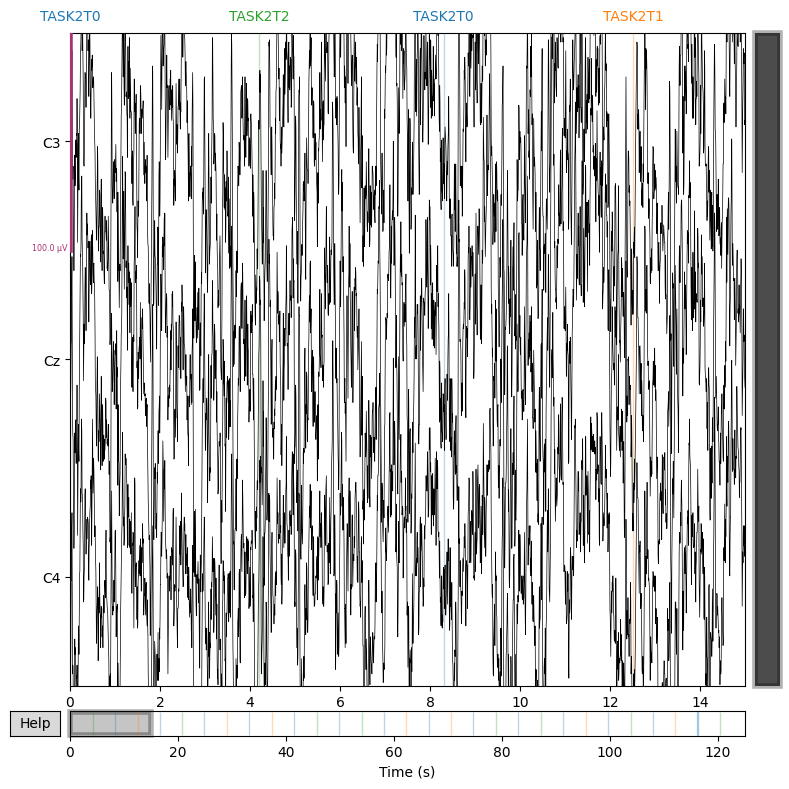

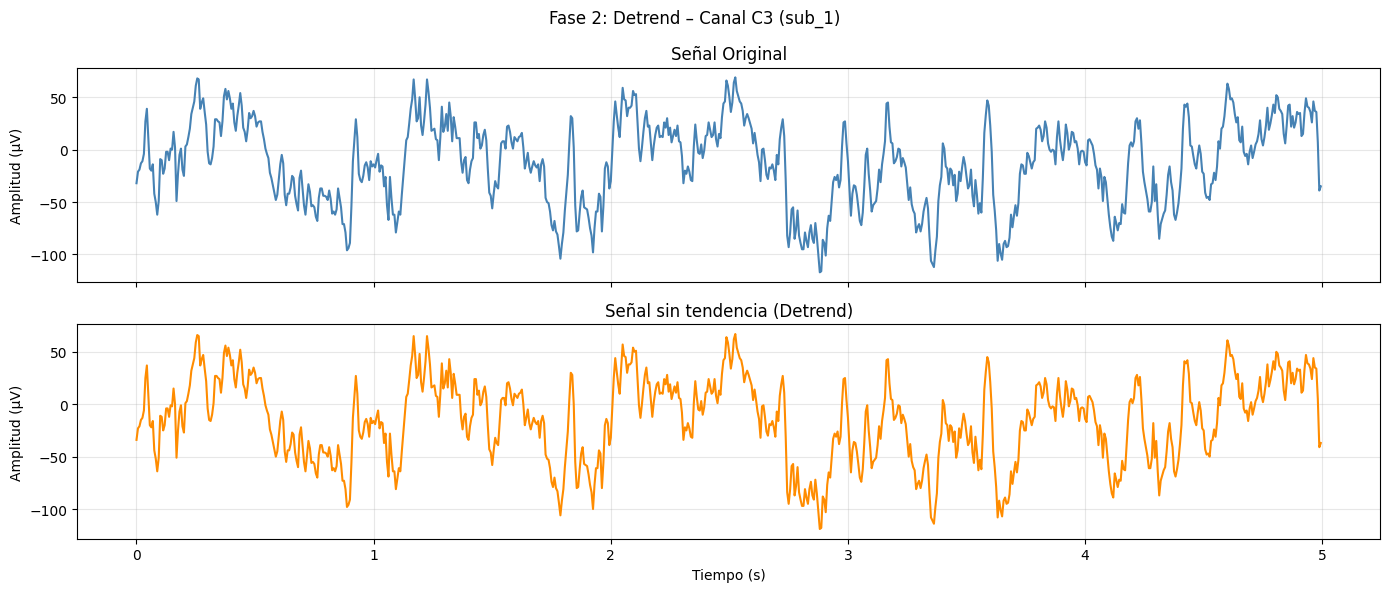

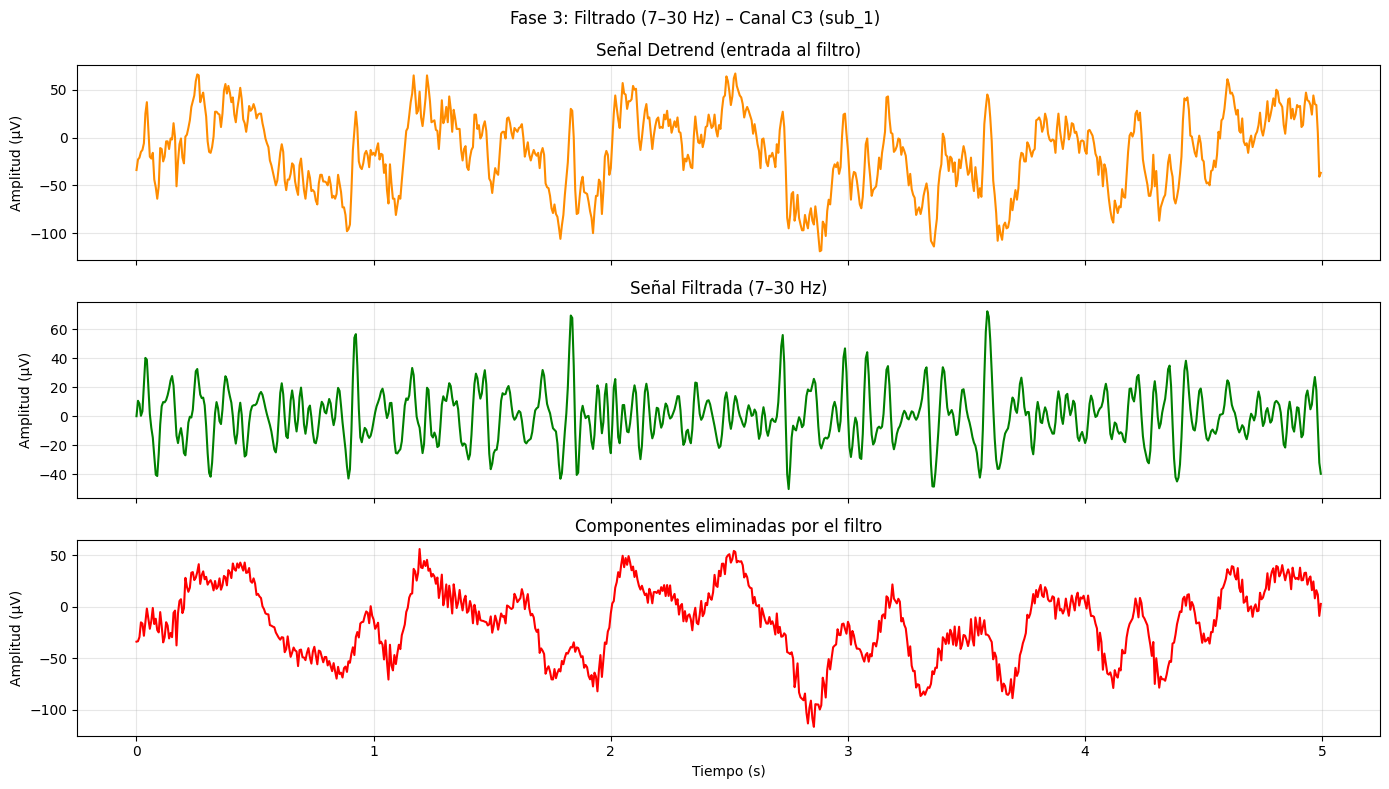

No data specified. Sanity checks related to the length of the signal relative to the filter order will be skipped.
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)


Orden del filtro FIR: 264


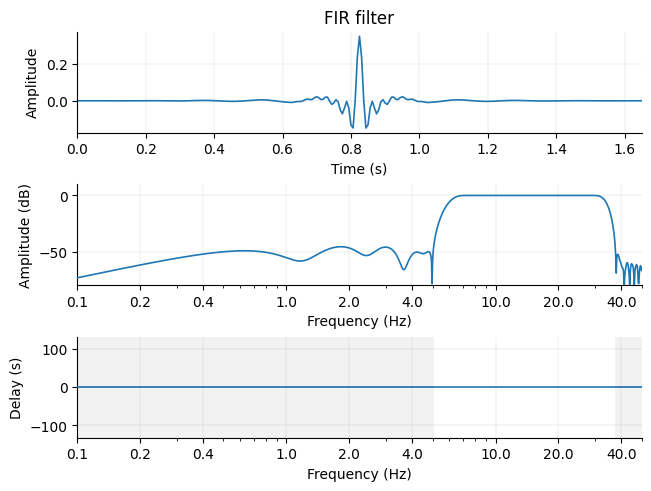

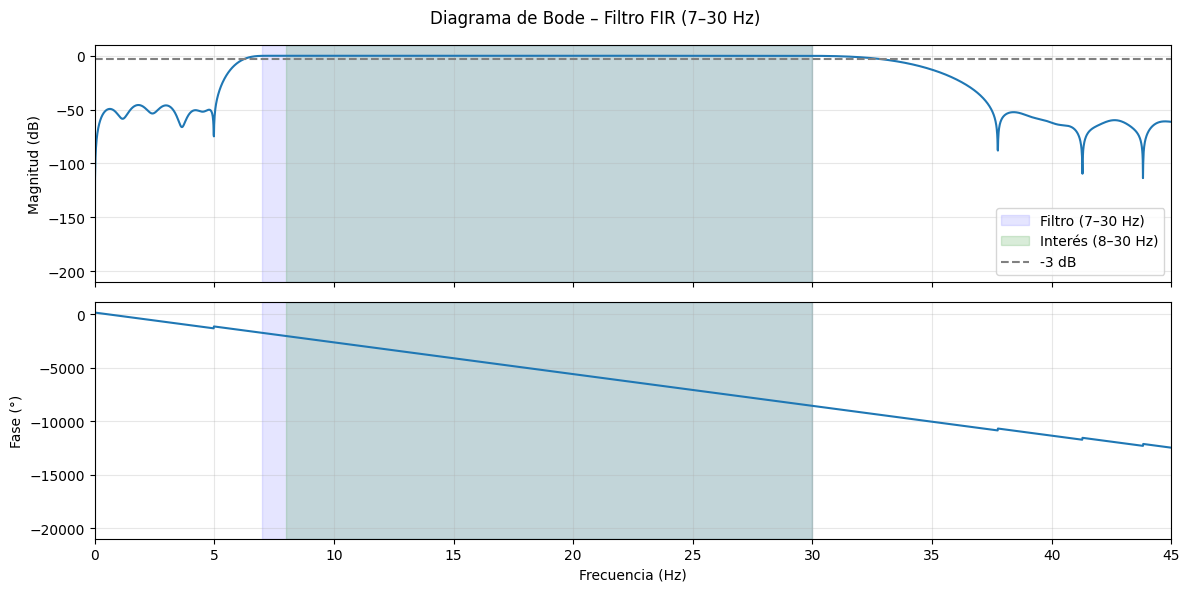

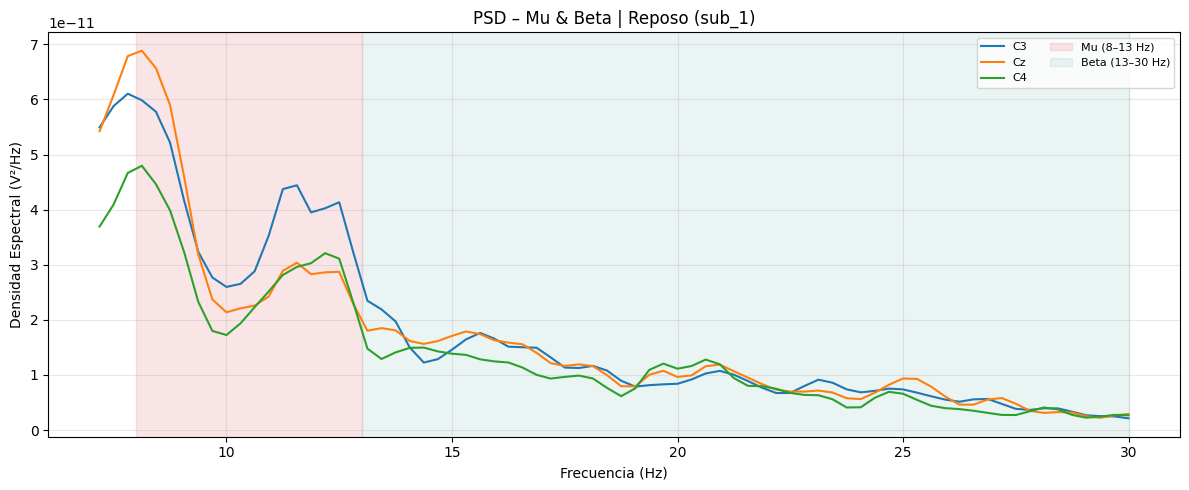

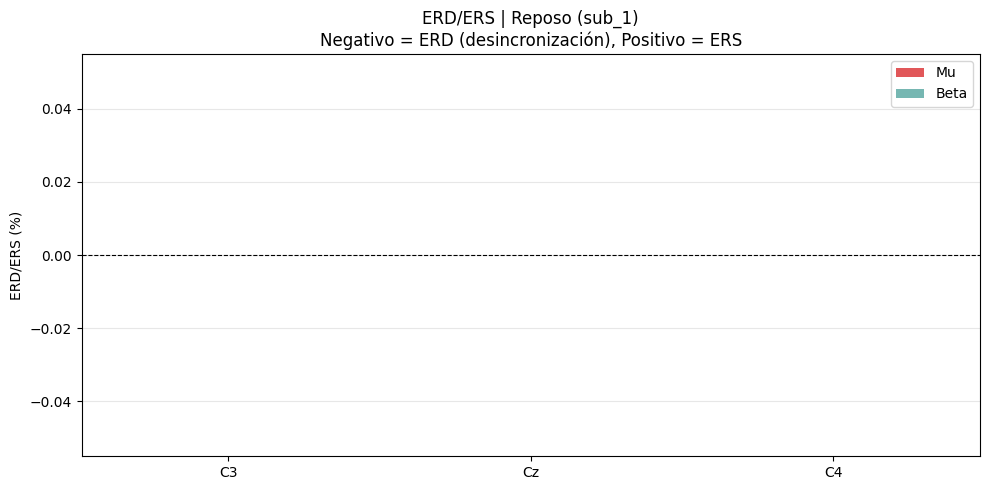

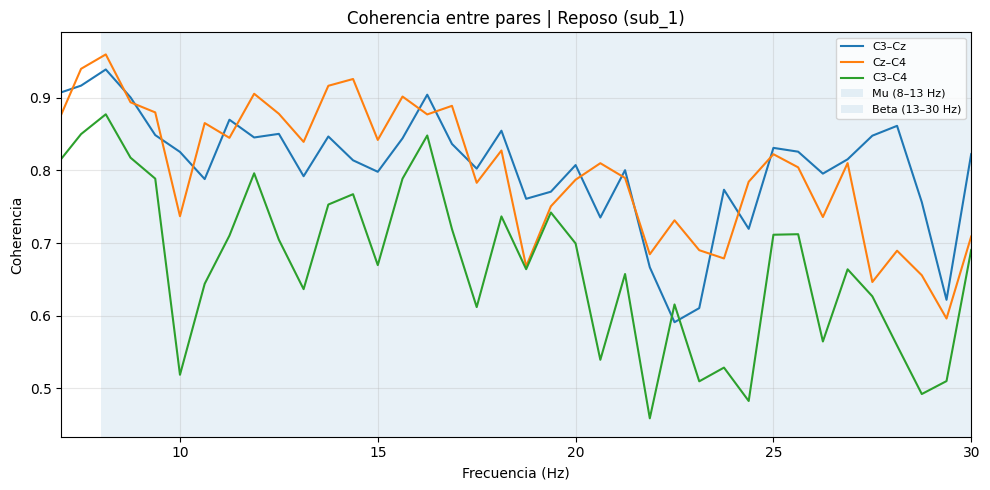

Not setting metadata
28 matching events found
Applying baseline correction (mode: mean)


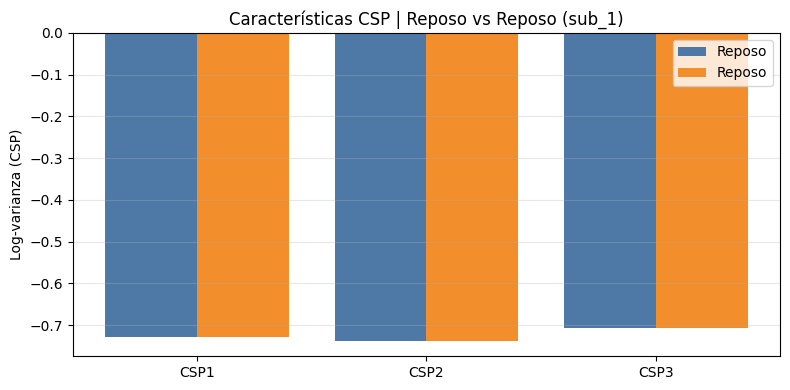

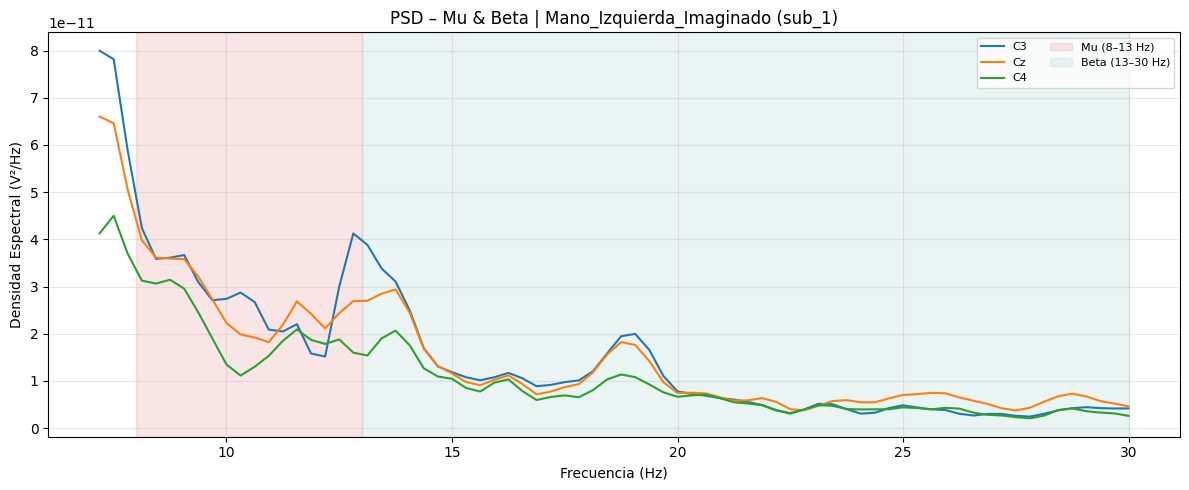

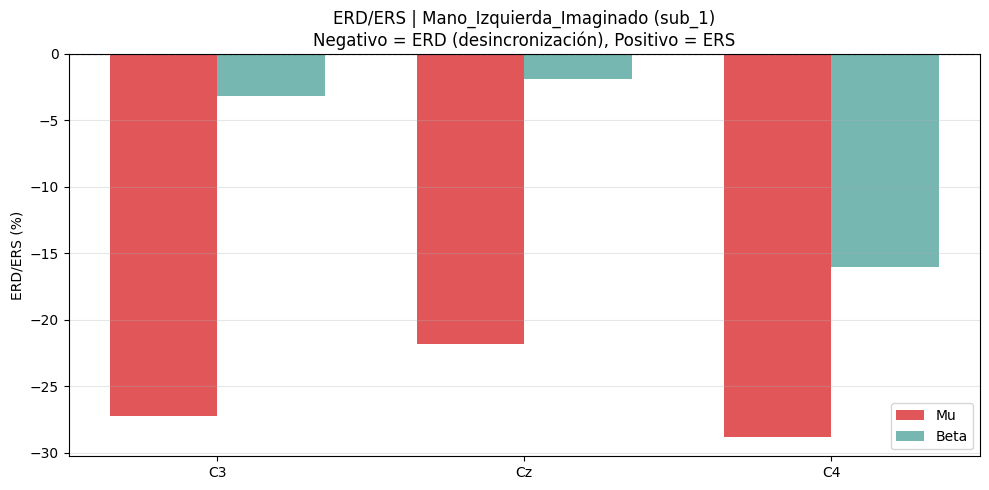

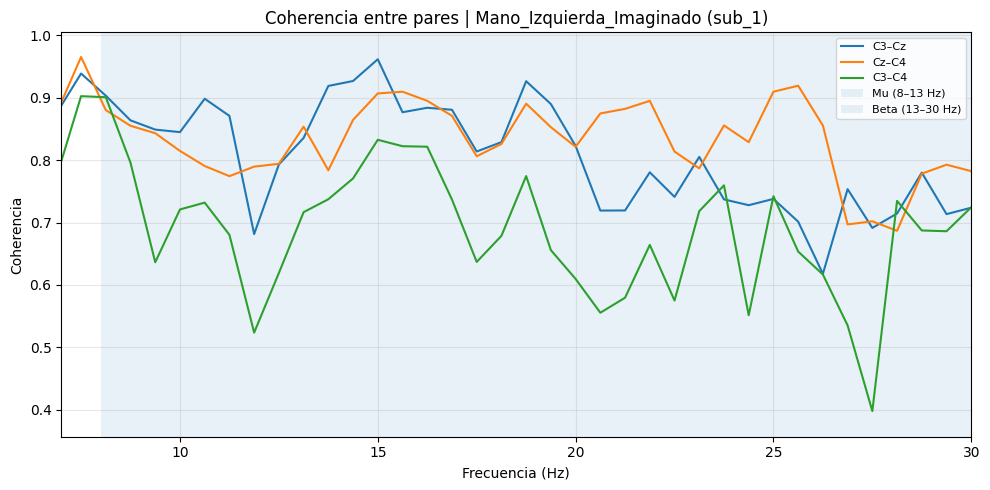

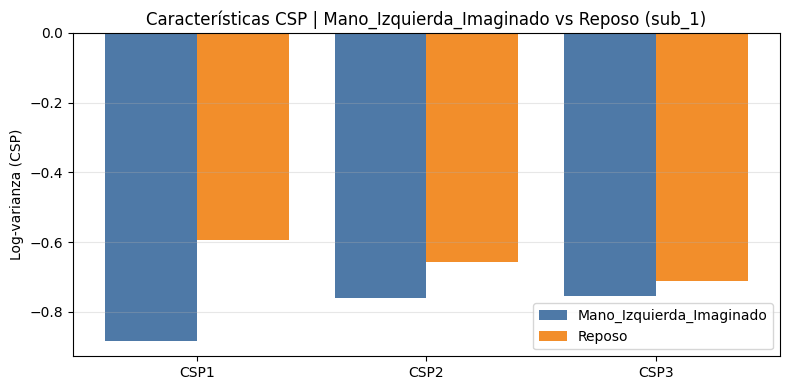

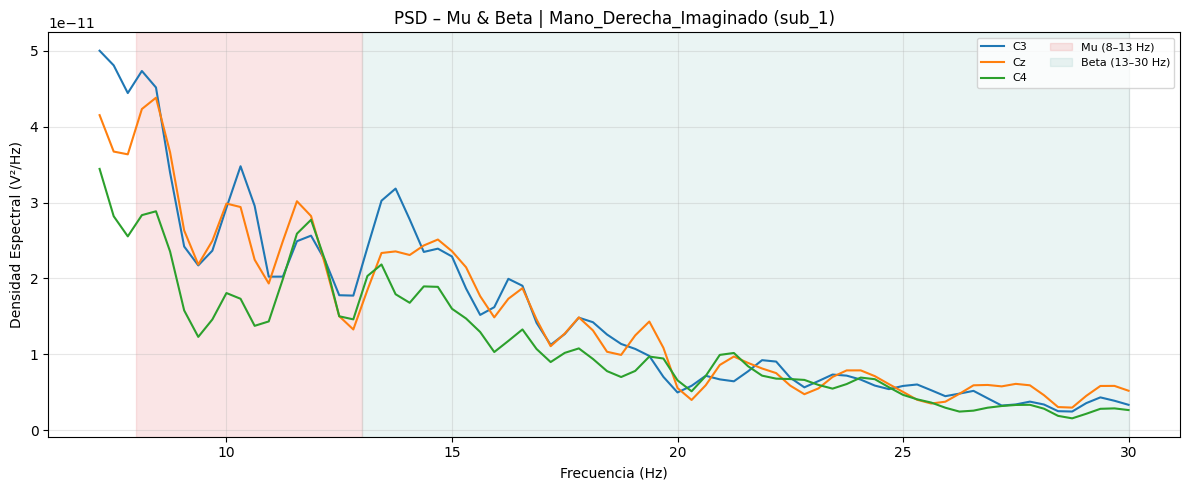

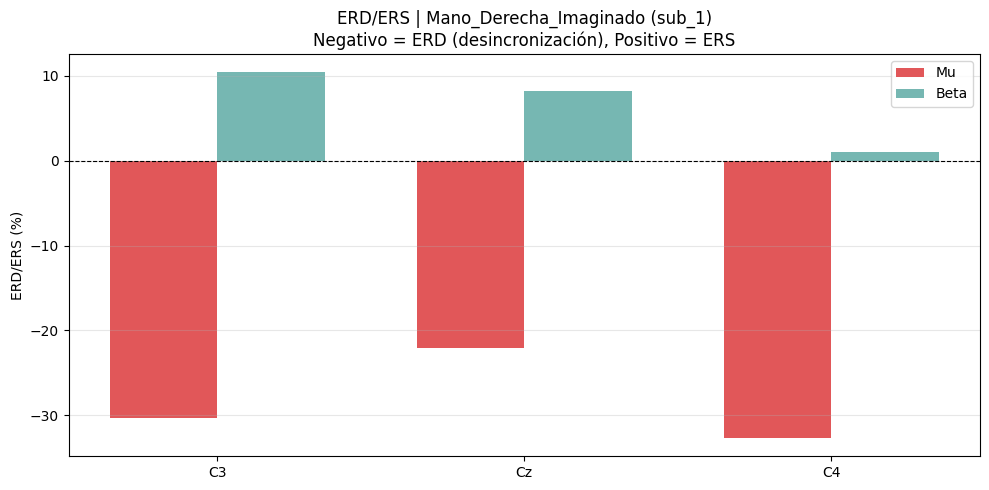

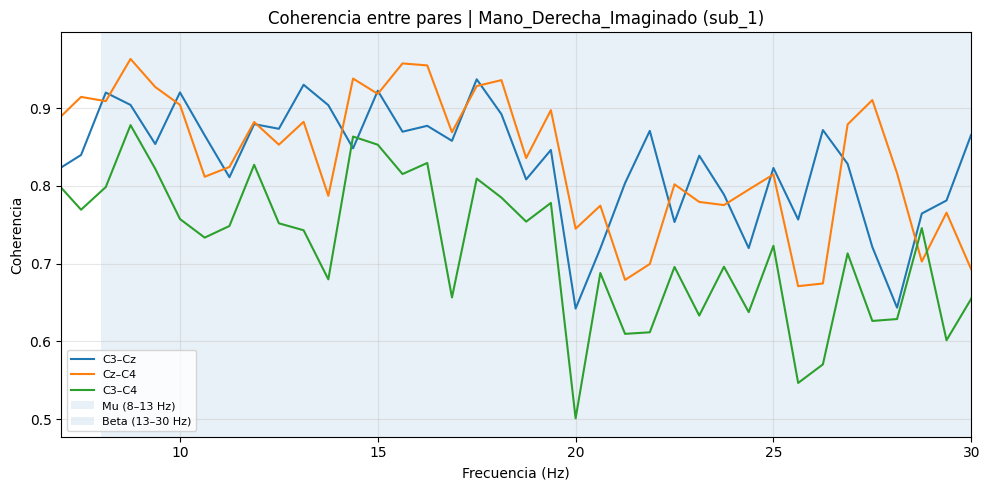

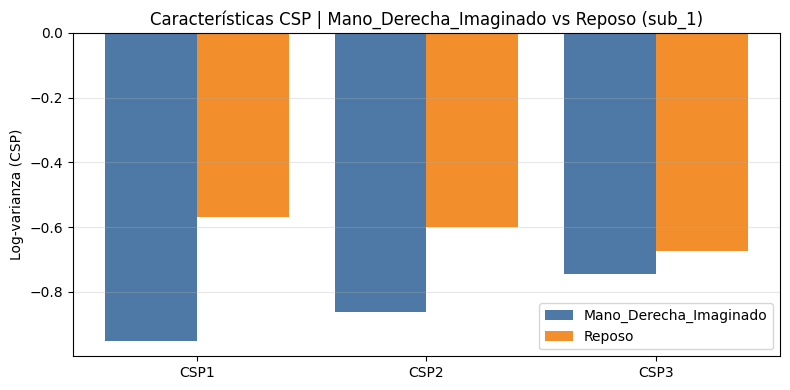

   Registro                     Tarea   Beta_C3   Beta_C4   Beta_Cz  CSP_comp1  CSP_comp2  CSP_comp3  Coh_Beta_C3_C4  Coh_Beta_C3_Cz  Coh_Beta_Cz_C4  Coh_Mu_C3_C4  Coh_Mu_C3_Cz  Coh_Mu_Cz_C4  ERD_ERS_Beta_C3  ERD_ERS_Beta_C4  ERD_ERS_Beta_Cz  ERD_ERS_Mu_C3  ERD_ERS_Mu_C4  ERD_ERS_Mu_Cz     Mu_C3     Mu_C4     Mu_Cz
0     sub_1                    Reposo  0.390923  0.428871  0.416631  -0.727164  -0.737627  -0.707452        0.641404        0.782294        0.772981      0.732073      0.858265      0.870334         0.000000         0.000000         0.000000       0.000000       0.000000       0.000000  0.476716  0.450349  0.438380
1     sub_1  Mano_Izquierda_Imaginado  0.425731  0.450155  0.456825  -0.883109  -0.760066  -0.754912        0.677679        0.793878        0.833558      0.701122      0.838012      0.817657        -3.127960       -16.030244        -1.888258     -27.257623     -28.833269     -21.827787  0.389638  0.400449  0.382805
2     sub_1    Mano_Derecha_Imaginado  0.495048  

In [24]:
# EJECUCIÓN
base_path   = 'Lab_EEG_Imagineria'
df_completo = construir_dataframe_completo(base_path)
print(df_completo.to_string())
df_completo.to_csv('resultados_completos.csv', index=False)

### Referencias 

[1] J.-X. Mi, R.-F. Li, K. Liu, and W. Li, "Exploring multi-scale time group for common spatial pattern feature based motor imagery EEG classification," Biomedical Signal Processing and Control, vol. 112, p. 108591, 2026. [En línea]. Disponible en: https://www.sciencedirect.com/science/article/abs/pii/S1746809425011024?fr=RR-2&ref=pdf_download&rr=9fbcc6845fedae73 

[2] D. P. Changoluisa Romero y F. J. Escalante Viteri, "Diseño e implementación de un sistema de adquisición de ondas cerebrales (EEG) de seis canales y análisis en tiempo, frecuencia y coherencia," Proyecto de titulación, Facultad de Ingeniería Eléctrica y Electrónica, Escuela Politécnica Nacional, Quito, Ecuador, 2012. [En línea]. Disponible en: http://bibdigital.epn.edu.ec/handle/15000/4454 

[3] W. Jian, M. Chen, and D. J. McFarland, "EEG based zero-phase phase-locking value (PLV) and effects of spatial filtering during actual movement," Brain Research Bulletin, 2017. [En línea]. Disponible en: https://www-sciencedirect-com.udea.lookproxy.com/science/article/pii/S0361923017300527 

[4] Stam, C.J., Nolte, G., & Daffertshofer, A. (2007). Phase lag index: Assessment of functional connectivity from multi channel EEG and MEG with diminished bias from common sources. Human Brain Mapping,[En linea]. Disponible en: https://pmc.ncbi.nlm.nih.gov/articles/PMC6871367/ 

[5] Martínez-Cagigal, V., Santamaría-Vázquez, E., & Hornero, R. (2019). Asynchronous Control of P300-Based Brain–Computer Interfaces Using Sample Entropy. Entropy, 21(3), 230.[En linea]. Disponible en: https://www.mdpi.com/1099-4300/21/3/230

[6] https://pmc.ncbi.nlm.nih.gov/articles/PMC6471241/  

[7] https://mne.tools/stable/index.html?utm_source=chatgpt.com

[8] https://docs.scipy.org/doc/scipy/reference/signal.html?utm_source=chatgpt.com 
